<a href="https://colab.research.google.com/github/Velgarath/recomendador_juegos_bgg/blob/main/juegosBGG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PASO 0. IMPORTACION DE LIBRERIAS**

In [ ]:
import re
import requests
import pandas as pd
import xml.etree.ElementTree as ET
import time
import os
import shutil
from google.colab import userdata
from google.colab import drive
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

**PASO 1: MONTAMOS GOOGLE DRIVE EN COLAB PARA RECUPERAR INFORMACION**

In [ ]:
#MONTAMOS EL DRIVE DE GOOGLE
from google.colab import drive

# 1. Intentamos desmontar de forma limpia usando la herramienta de disco de Colab
try:
    drive.flush_and_unmount()
    print("Unidad desmontada limpiamente.")
except Exception as e:
    print("No se pudo desmontar de forma estándar (puede que no estuviera montado):", e)

# 2. Si quedan carpetas residuales en la ruta, las eliminamos a la fuerza
mountpoint = '/content/drive'
if os.path.exists(mountpoint):
    try:
        # Eliminamos la carpeta "drive" y todo su contenido conflictivo local
        shutil.rmtree(mountpoint)
        print(f"Carpeta residual '{mountpoint}' eliminada con éxito.")
    except Exception as e:
        print(f"No se pudo eliminar la carpeta {mountpoint} directamente: {e}")
        print("Intentando forzar la eliminación por consola...")
        # Alternativa por comandos de sistema si Python encuentra el directorio bloqueado
        !umount -l /content/drive
        !rm -rf /content/drive

# 3. Volvemos a montar desde cero de forma limpia
print("Volviendo a montar Drive...")
drive.mount(mountpoint)

Drive not mounted, so nothing to flush and unmount.
Unidad desmontada limpiamente.
Volviendo a montar Drive...
Mounted at /content/drive


In [ ]:
#ESTE CODIGO ME RENUEVA LOS FICHEROS DE KAGGLE DE LA BGG Y ME LOS METE EN GOOGLE DRIVE
#Importacion de la variable de entorno para conectarme a KAGGLE y descargar los datos
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_API_TOKEN')
    print("¡Tokens de Kaggle cargados de forma segura desde los secretos de Colab!")
except Exception as e:
    print("Error:",e)

#Descarga de los datos de la web de Kaggle
!kaggle datasets download -d threnjen/board-games-database-from-boardgamegeek -p "/content/drive/MyDrive/Colab Notebooks/IA Juegos/Datos/" --unzip


¡Tokens de Kaggle cargados de forma segura desde los secretos de Colab!
Dataset URL: https://www.kaggle.com/datasets/threnjen/board-games-database-from-boardgamegeek
License(s): CC-BY-SA-3.0
board-games-database-from-boardgamegeek.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
#LECTURA DE LOS DATOS CSV DE KAGGLE
#Leemos el fichero games.csv y lo metemos en un DataFrame
df_games = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/IA Juegos/Datos/games.csv")

In [21]:
# LECTURA DE LOS DATOS DE LA BGG
# Este link descarga el XML de los juegos que poseo. NO inlcuye expansiones
# https://boardgamegeek.com/xmlapi2/collection?username=velgarath&subtype=boardgame&excludesubtype=boardgameexpansion&own=1
# Este link descarga el XML de los juegos que he puntuado en la BGG independientemente de si los tengo o no los tengo. No incluye expansiones.
# https://boardgamegeek.com/xmlapi2/collection?username=velgarath&subtype=boardgame&excludesubtype=boardgameexpansion&rated=1


#Esta funcion es necesaria para limpiar los ampersands del XML
#Es un problema conocido de la exportacion de los XML de la BGG
def limpia_ampersands(texto_xml):
    # Reemplaza & que NO sea parte de una entidad válida (&amp; &lt; &gt; &quot; &apos; &#123; &#x1F;)
    return re.sub(r'&(?!amp;|lt;|gt;|quot;|apos;|#\d+;|#x[0-9a-fA-F]+;)', '&amp;', texto_xml)

#drive.mount('/content/drive', force_remount=True)

# Abrimos por separado los juegos poseidos por luis y los juegos puntuiados por luis
f = open("/content/drive/MyDrive/Colab Notebooks/IA Juegos/Datos/velgarath_games_owned.xml", "r")
juegos_owned_luis = limpia_ampersands(f.read())
f.close()

f = open("/content/drive/MyDrive/Colab Notebooks/IA Juegos/Datos/velgarath_games_rated.xml", "r")
juegos_rated_luis = limpia_ampersands(f.read())
f.close()





In [22]:
# PARSEADO XML DE UNA COLECCION DE JUEGOS DE MESA IMPORTADO DE LA BGG

def convierte_xml_a_dataframe(respuesta):
    raiz = ET.fromstring(respuesta)
    lista_juegos = []

    for item in raiz.findall('item'):
        objectid = item.attrib.get('objectid')  # clave para el merge con Kaggle
        subtype = item.attrib.get('subtype')

        name = item.find('name').text if item.find('name') is not None else 'Desconocido'
        year = item.find('yearpublished').text if item.find('yearpublished') is not None else 'N/A'
        numplays = item.find('numplays').text if item.find('numplays') is not None else 'N/A'

        status = item.find('status')
        own = status.attrib.get('own') if status is not None else None
        wishlist = status.attrib.get('wishlist') if status is not None else None
        preordered = status.attrib.get('preordered') if status is not None else None

        # stats puede faltar según cómo se exportó el XML, así que protegemos todo
        stats = item.find('stats')
        if stats is not None:
            min_players = stats.attrib.get('minplayers')
            max_players = stats.attrib.get('maxplayers')
            playing_time = stats.attrib.get('playingtime')
            num_owned = stats.attrib.get('numowned')
            etiqueta_rating = stats.find('rating')
            user_rating = etiqueta_rating.attrib.get('value') if etiqueta_rating is not None else 'N/A'
            average_elem = stats.find('rating/average')
            avg_rating = average_elem.attrib.get('value') if average_elem is not None else None
        else:
            min_players = max_players = playing_time = num_owned = None
            user_rating = 'N/A'
            avg_rating = None

        lista_juegos.append({
            'BGGId': objectid,
            'Subtype': subtype,
            'IsExpansion': subtype == 'boardgameexpansion',
            'Name': name,
            'YearPublished': year,
            'AvgRating': avg_rating,
            'UserRating': user_rating,
            'MinPlayers': min_players,
            'MaxPlayers': max_players,
            'PlayingTime': playing_time,
            'NumOwned': num_owned,
            'NumPlays': numplays,
            'Own': own,
            'Wishlist': wishlist,
            'Preordered': preordered,
        })

    df_lista_juegos = pd.DataFrame(lista_juegos)

    columns_to_convert = ['YearPublished', 'AvgRating', 'UserRating',
                          'MinPlayers', 'MaxPlayers',
                          'PlayingTime', 'NumOwned', 'NumPlays']
    df_lista_juegos[columns_to_convert] = df_lista_juegos[columns_to_convert].apply(pd.to_numeric, errors='coerce')
    df_lista_juegos['BGGId'] = pd.to_numeric(df_lista_juegos['BGGId'], errors='coerce').astype('Int64')

    return df_lista_juegos

# Creamos 2 dataframes
# el data frame RATED lo usaremos para entrenar el modelo.
# el data frame OWNED no lo usaremos en la fase de aprendizaje. Lo usaremos para ver qué juegos de los que recomienda el modelo YA lo tenemos.
df_rated = convierte_xml_a_dataframe(juegos_rated_luis)
df_owned = convierte_xml_a_dataframe(juegos_owned_luis)

#Hemos visto que el tipo BGG_ID es "Int64". Lo pasamos a "int64 para que sea igual de la BD de Kagle"
df_owned['BGGId'] = df_owned['BGGId'].astype('int64')
df_rated['BGGId'] = df_rated['BGGId'].astype('int64')

print("Ratings válidos en OWNED:", df_owned['UserRating'].notna().sum())
print("Ratings válidos en RATED:", df_rated['UserRating'].notna().sum())

print("\nOwned:")
print(df_owned['Own'].value_counts(dropna=False))

print("\nRated:")
print(df_rated['Own'].value_counts(dropna=False))



Ratings válidos en OWNED: 222
Ratings válidos en RATED: 279

Owned:
Own
1    517
Name: count, dtype: int64

Rated:
Own
1    222
0     57
Name: count, dtype: int64


Juegos puntuados disponibles en BGG: 279
Juegos utilizados finalmente para entrenar: 259
Juegos puntuados que no aparecen en df_games: 20
 BGGId                                                             Name  UserRating Own
275586              Banish the Snakes: A Game of St. Patrick in Ireland         1.0   1
333981                                                        Bear Raid         8.3   1
342921          The British Way: Counterinsurgency at the End of Empire         9.2   1
400602                                                       Civolution         8.2   1
295072                                              Downfall of Empires         5.0   0
345594                                      Downfall of the Third Reich         5.0   0
440007                                              The Druids of Edora         8.9   1
367527                                   Fields of Fire: Deluxe Edition         9.5   1
420087                                                           Flip 

<Axes: >

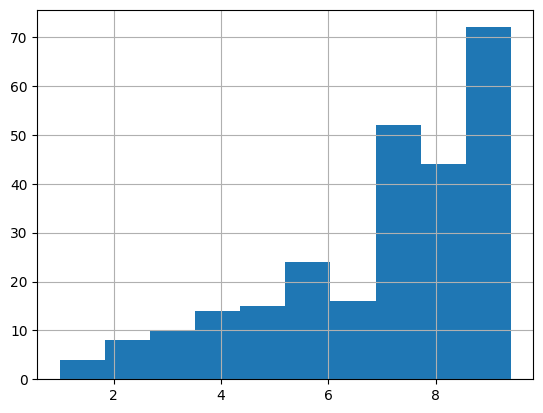

In [24]:
# ==============================================================
# PREPARACIÓN DEL DATAFRAME DE ENTRENAMIENTO
# ==============================================================

# df_rated contiene exclusivamente los juegos base que he puntuado,
# independientemente de si los poseo actualmente o no.
#
# Para entrenar solo necesitamos:
#   - BGGId: clave para cruzar con la base global de juegos
#   - UserRating: mi puntuación, que será el objetivo "y" del modelo
#
# Hacemos INNER JOIN con df_games para incorporar las características
# de cada juego que utilizará el modelo para aprender.

cols_luis = ['BGGId', 'UserRating']

df_train = df_rated[cols_luis].merge(
    df_games,
    on='BGGId',
    how='inner'
)

# Sustituimos valores ausentes por la mediana de la columna.
df_train['ComAgeRec'] = df_train['ComAgeRec'].fillna(
    df_train['ComAgeRec'].median()
)

df_train['LanguageEase'] = df_train['LanguageEase'].fillna(
    df_train['LanguageEase'].median()
)

print(f"Juegos puntuados disponibles en BGG: {len(df_rated)}")
print(f"Juegos utilizados finalmente para entrenar: {len(df_train)}")

##BORRAR LUEGO
ids_train = set(df_games['BGGId'])

juegos_sin_match = df_rated[
    ~df_rated['BGGId'].isin(ids_train)
]

print(f"Juegos puntuados que no aparecen en df_games: {len(juegos_sin_match)}")

print(
    juegos_sin_match[
        ['BGGId', 'Name', 'UserRating', 'Own']
    ].to_string(index=False)
)


ids_sin_match = juegos_sin_match['BGGId'].tolist()

print(ids_sin_match)

print(
    df_games[
        df_games['BGGId'].isin(ids_sin_match)
    ]
)
#######

print(df_train['UserRating'].describe())

print(
    df_train['UserRating']
    .value_counts()
    .sort_index()
)

df_train['UserRating'].hist(bins=10)

In [25]:
# LANZAMOS EL MACHINE LEARNING
# Creamos la matriz de parámetros X y el vector y de respuestas.

features = [
    'GameWeight', 'MinPlayers', 'MaxPlayers', 'MfgPlaytime',
    'ComMinPlaytime', 'ComMaxPlaytime', 'ComAgeRec', 'LanguageEase',
    'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family',
    'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens'
]

X = df_train[features]
y = df_train['UserRating']


# ==============================================================
# BASELINE: PREDECIR SIEMPRE LA NOTA MEDIA
# ==============================================================

modelo_dummy = DummyRegressor(strategy='mean')

scores_dummy = cross_val_score(
    modelo_dummy,
    X,
    y,
    cv=5,
    scoring='neg_mean_absolute_error'
)

mae_dummy = -scores_dummy.mean()


# ==============================================================
# REGRESIÓN LINEAL
# ==============================================================

modelo = LinearRegression()

# Scikit-learn devuelve el MAE negativo por convención.
scores = cross_val_score(
    modelo,
    X,
    y,
    cv=5,
    scoring='neg_mean_absolute_error'
)

mae_modelo = -scores.mean()

# Entrenamos con todos los datos para inspeccionar los pesos.
modelo.fit(X, y)

pesos = pd.Series(
    modelo.coef_,
    index=X.columns
).sort_values()


# ==============================================================
# RIDGE
# ==============================================================

# El pipeline estandariza las variables antes de aplicar Ridge.
modelo_ridge = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

scores_ridge = cross_val_score(
    modelo_ridge,
    X,
    y,
    cv=5,
    scoring='neg_mean_absolute_error'
)

mae_ridge = -scores_ridge.mean()

modelo_ridge.fit(X, y)

pesos_ridge = pd.Series(
    modelo_ridge.named_steps['ridge'].coef_,
    index=X.columns
).sort_values()


# ==============================================================
# RESUMEN LEGIBLE DE RESULTADOS
# ==============================================================

#Hacemos un data_frame que contiene los resultados de cada modelo.
comparacion_modelos = pd.DataFrame({
    'Modelo': [
        'Dummy (media)',
        'Regresión lineal',
        'Ridge'
    ],
    'MAE': [
        mae_dummy,
        mae_modelo,
        mae_ridge
    ],
    'Mejora vs baseline': [
        0.0,
        mae_dummy - mae_modelo,
        mae_dummy - mae_ridge
    ]
})

print('\n' + '=' * 68)
print('COMPARACIÓN DEL RENDIMIENTO DE LOS MODELOS')
print('=' * 68)

print(
    comparacion_modelos.to_string(
        index=False,
        formatters={
            'MAE': lambda valor: f'{valor:.3f}',
            'Mejora vs baseline': lambda valor: f'{valor:+.3f}'
        }
    )
)

print('\nCuanto menor es el MAE, mejor predice el modelo.')


# ==============================================================
# RESULTADOS DE CADA PLIEGUE
# ==============================================================

print('\n' + '-' * 68)
print('MAE EN CADA PLIEGUE DE LA VALIDACIÓN CRUZADA')
print('-' * 68)

print(f"Dummy            : {(-scores_dummy).round(3)}")
print(f"Regresión lineal : {(-scores).round(3)}")
print(f"Ridge            : {(-scores_ridge).round(3)}")

# ==============================================================
# COEFICIENTES
# ==============================================================

print('\n' + '-' * 68)
print('COEFICIENTES APRENDIDOS')
print('-' * 68)

print('\nRegresión lineal:')
print(pesos.to_string())

print('\nRidge (variables estandarizadas):')
print(pesos_ridge.to_string())


COMPARACIÓN DEL RENDIMIENTO DE LOS MODELOS
          Modelo   MAE Mejora vs baseline
   Dummy (media) 1.651             +0.000
Regresión lineal 1.354             +0.296
           Ridge 1.354             +0.297

Cuanto menor es el MAE, mejor predice el modelo.

--------------------------------------------------------------------
MAE EN CADA PLIEGUE DE LA VALIDACIÓN CRUZADA
--------------------------------------------------------------------
Dummy            : [1.588 1.728 1.638 1.579 1.719]
Regresión lineal : [1.049 1.249 1.517 1.417 1.541]
Ridge            : [1.048 1.251 1.516 1.415 1.538]

--------------------------------------------------------------------
COEFICIENTES APRENDIDOS
--------------------------------------------------------------------

Regresión lineal:
Cat:Childrens    -2.507251e+00
Cat:Thematic     -9.747677e-01
Cat:Party        -9.343447e-01
Cat:Family       -4.160125e-01
MaxPlayers       -3.237077e-02
LanguageEase     -1.222960e-03
ComMinPlaytime   -4.804997e-04
Ca

In [ ]:
#LINEAR REGRESSION - 2
#Vamos a hacer un ranking de los juegos que me podrian gustar más.
#Fijaremos más adelante el umbral. De momento hagamos un TOP 20
#Vamoa a preparar los siguientes datos
#X_train = la matriz de mis juegos puntuados, que son los datos de entrenamiento
#y_train = la puntuación dado a cada uno de los juegos que tengo puntuados.
#X_nuevos = la matriz de juegos de Kagle que NO tengo

features = ['GameWeight', 'MinPlayers', 'MaxPlayers', 'MfgPlaytime',
            'ComMinPlaytime', 'ComMaxPlaytime', 'ComAgeRec', 'LanguageEase',
            'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family',
            'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens']


# Todos los BGGId que ya tienes (puntuados o no) en tu colección
ids_luis = df_luis['BGGId']

# Candidatos: juegos de Kaggle que NO están en tu colección
df_recomendar = df_games[~df_games['BGGId'].isin(ids_luis)].copy()
print(f"Candidatos que pasamos para recomendar: {len(df_recomendar)}")

X_train = df_train[features]        # entrada de ENTRENAMIENTO (tus juegos base puntuados)
y_train = df_train['UserRating']    # objetivo: tus notas

X_nuevos = df_recomendar[features]  # entrada de PREDICCIÓN (los juegos que no tienes)

# este vector saca las medianas de todos los parámetros X del set de en0trenamiento
# Lo hacemos para normalizar los NaN datos de juegos que no tengo "X_nuevos"
# Un tema importante es que normalizamos con datos DE ENTRENAMIENTO. Nunca con datos de prediccion.
medianas_train = X_train.median()
X_nuevos = X_nuevos.fillna(medianas_train)

#Ahora tenemos los datos preparados, que son los siguientes
#X_train = la matriz de mis juegos puntuados, que son los datos de entrenamiento
#y_train = la puntuación dado a cada uno de los juegos que tengo puntuados.
#X_nuevos = la matriz de juegos de Kagle que NO tengo

#Pasamos el modelo
# La validación cruzada y el modelo final, ahora con los nombres nuevos
modelo_ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
scores_ridge = cross_val_score(modelo_ridge, X_train, y_train, cv=5,
                               scoring='neg_mean_absolute_error')
modelo_ridge.fit(X_train, y_train)

# Predecir la nota de cada juego candidato
df_recomendar['nota_predicha'] = modelo_ridge.predict(X_nuevos)

df_recomendar['posicion'] = df_recomendar['nota_predicha'] \
    .rank(ascending=False, method='min').astype(int)

MIN_VOTOS = 1000
#Generamos el ranking quitando los juegos con menos de MIN_VOTOS y ordenando de mayor a menor
# Filtramos SOLO al construir el ranking. df_recomendar queda intacto.
ranking = df_recomendar[df_recomendar['NumUserRatings'] >= MIN_VOTOS] \
              .sort_values('nota_predicha', ascending=False)



# Top 20 — mostramos las features que el modelo dijo que más te gustan,
# para que TÚ juzgues si las recomendaciones tienen sentido
columnas_a_ver = ["posicion", 'Name', 'nota_predicha', 'GameWeight', 'Cat:War', 'Cat:Strategy']
print(ranking[columnas_a_ver].head(20).to_string())



# Buscar juegos con "18" en el nombre dentro del ranking completo (sin filtrar por votos)
mask_18xx = df_recomendar['Name'].str.contains(r'^18\d\d', na=False, regex=True) \
            & (df_recomendar['Cat:War'] == 0)
cols = ["posicion", 'Name', 'nota_predicha', 'GameWeight', 'Cat:War', 'Cat:Strategy']
print(df_recomendar[mask_18xx].sort_values('nota_predicha', ascending=False)[cols].head(15).to_string())


Candidatos que pasamos para recomendar: 21232
       posicion                                                               Name  nota_predicha  GameWeight  Cat:War  Cat:Strategy
16460         5                                                  Imperial Struggle      10.548025      3.8931        1             1
209           6                                              Advanced Squad Leader      10.540446      4.7321        1             0
18079        17                                                               Root      10.268692      3.7068        1             1
1187         31                                                 Star Fleet Battles      10.093229      4.1830        1             0
809          36                                                       Squad Leader      10.063063      4.0365        1             0
6733         62                              Advanced Squad Leader: Starter Kit #3       9.934680      3.9000        1             0
5944        131        